### Introduction
#### I'm using the insurance.csv Medical Cost Personal dataset from kaggle.com to predict the annual medical cost billed by an insurance company over $16,000.  I will be using the Decision Tree Classifier, Random Forest Classifier, and SVC classifier to determine the best model. I will also examine the relationship between age and medical costs billed by an insurance company. The Python modules I will be using are pandas, numpy, matplotlib, seaborn, and the following from sklearn: accuracy_score, StandardScaler, OneHotEncoder, ColumnTransformer, Pipeline, train_test_split, SVC, DecisionTreeClassifier, tree,  classification_report, RandomForestClassifier, and GridSearchCV. The link to the dataset is: https://www.kaggle.com/datasets/mirichoi0218/insurance/data

In [311]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split

In [313]:
df = pd.read_csv('insurance.csv')
dfc = df.copy()

In [315]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [317]:
df.shape

(1338, 7)

### Checking for null values

In [320]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

### Printing unique values for sex, smoker, and region for mapping or one-hot encoding later.

In [323]:
print(df['smoker'].unique)
print(df['sex'].unique)
print(df['region'].unique)

<bound method Series.unique of 0       yes
1        no
2        no
3        no
4        no
       ... 
1333     no
1334     no
1335     no
1336     no
1337    yes
Name: smoker, Length: 1338, dtype: object>
<bound method Series.unique of 0       female
1         male
2         male
3         male
4         male
         ...  
1333      male
1334    female
1335    female
1336    female
1337    female
Name: sex, Length: 1338, dtype: object>
<bound method Series.unique of 0       southwest
1       southeast
2       southeast
3       northwest
4       northwest
          ...    
1333    northwest
1334    northeast
1335    southeast
1336    southwest
1337    northwest
Name: region, Length: 1338, dtype: object>


### Creating 'high_cost' column to predict if charges are greater than 16,000.

In [326]:
# Classification example: predict if charges > 16000 (you can change threshold)
df['high_cost'] = (df['charges'] > 16000).astype(int)

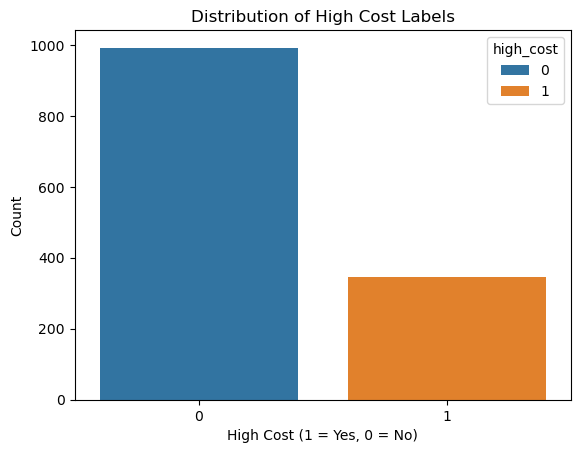

In [328]:
sns.countplot(x="high_cost", hue="high_cost", data=df, palette=["#1f77b4", "#ff7f0e"])
plt.title("Distribution of High Cost Labels")
plt.xlabel("High Cost (1 = Yes, 0 = No)")
plt.ylabel("Count")
plt.show()

### Exploring how likely a person of each age is to have high_cost

In [331]:
age_unique=sorted(df.age.unique())
print("age_unique")
print(age_unique)

print("+++++++++++++++++")
age_high_cost_values=df.groupby('age')['high_cost'].count().values

print("age_high_cost_values")
print(age_high_cost_values)

mean_high_cost=[]

for i, age in enumerate(age_unique):
    mean_high_cost.append(sum(df[df['age']==age].high_cost)/age_high_cost_values[i])
    
print("mean high cost")
print(mean_high_cost)

age_unique
[18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64]
+++++++++++++++++
age_high_cost_values
[69 68 29 28 28 28 28 28 28 28 28 27 27 27 26 26 26 25 25 25 25 25 27 27
 27 27 27 29 29 29 29 28 29 29 29 28 28 26 26 26 25 25 23 23 23 23 22]
mean high cost
[0.13043478260869565, 0.3088235294117647, 0.3103448275862069, 0.10714285714285714, 0.21428571428571427, 0.32142857142857145, 0.2857142857142857, 0.25, 0.10714285714285714, 0.39285714285714285, 0.21428571428571427, 0.3333333333333333, 0.37037037037037035, 0.18518518518518517, 0.23076923076923078, 0.2692307692307692, 0.23076923076923078, 0.28, 0.24, 0.44, 0.04, 0.28, 0.2222222222222222, 0.07407407407407407, 0.2962962962962963, 0.5185185185185185, 0.25925925925925924, 0.2413793103448276, 0.20689655172413793, 0.41379310344827586, 0.27586206896551724, 0.17857142857142858, 0.27586206896551724, 0.20689

In [333]:
print(type(mean_high_cost))
print(list(age_unique))

df_age_high_cost = pd.DataFrame([age_unique, mean_high_cost])


print(df_age_high_cost)

<class 'list'>
[18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64]
          0          1          2          3          4          5   \
0  18.000000  19.000000  20.000000  21.000000  22.000000  23.000000   
1   0.130435   0.308824   0.310345   0.107143   0.214286   0.321429   

          6      7          8          9   ...         37         38  \
0  24.000000  25.00  26.000000  27.000000  ...  55.000000  56.000000   
1   0.285714   0.25   0.107143   0.392857  ...   0.230769   0.153846   

          39     40     41         42         43        44         45    46  
0  57.000000  58.00  59.00  60.000000  61.000000  62.00000  63.000000  64.0  
1   0.230769   0.08   0.28   0.304348   0.391304   0.26087   0.217391   0.5  

[2 rows x 47 columns]


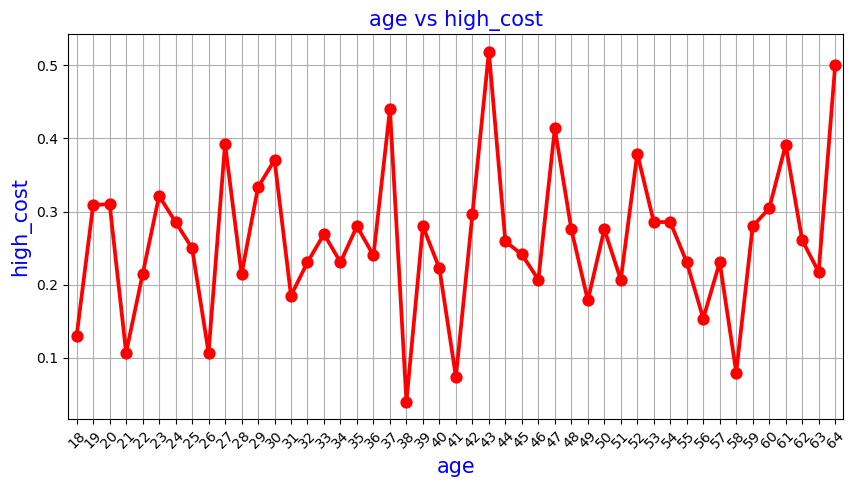

In [335]:
plt.figure(figsize=(10,5))
sns.pointplot(x=age_unique,y=mean_high_cost,color='red')
plt.xlabel('age',fontsize = 15,color='blue')
plt.xticks(rotation=45)
plt.ylabel('high_cost',fontsize = 15,color='blue')
plt.title('age vs high_cost',fontsize = 15,color='blue')
plt.grid()
plt.show()

### Observations: Given the sporadic nature of the results, there does not appear to be a linear relationship between age and high_cost in the dataset.

-----------------------------------------------------------------------------------------------------------------------------

### Mapping sex and smoker, then creating x df while dropping 'charges' and 'high_cost columns, then
### creating y dataframe with 'high_cost' as target.

In [339]:
# Features and target
df['sex'] = dfc['sex'].map({'female':0, 'male':1})
df['smoker'] = dfc['smoker'].map({'no':0, 'yes':1})
x = df.drop(['charges', 'high_cost'], axis=1)
y = df['high_cost']

### Train, Test, Split

In [342]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.20, random_state=42)

In [344]:
# Numerical features to scale
numeric_features = ['age', 'bmi', 'children']

# Categorical features to encode
categorical_features = ['sex', 'smoker', 'region']

### SVC Classifier

In [347]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', SVC())
])

In [349]:
# Fit the pipeline
clf_pipeline.fit(x_train, y_train)

# Predict
y_pred = clf_pipeline.predict(x_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))
print(f"Test Accuracy: {accuracy:.4f}")

              precision    recall  f1-score   support

           0       0.93      1.00      0.97       200
           1       1.00      0.79      0.89        68

    accuracy                           0.95       268
   macro avg       0.97      0.90      0.93       268
weighted avg       0.95      0.95      0.95       268

Test Accuracy: 0.9478


### Decision Tree Classifier

In [352]:
# Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),  # optional for Decision Trees
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

# Decision tree pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

In [354]:
# Fit the pipeline
pipeline.fit(x_train, y_train)
y_pred = pipeline.predict(x_test)

print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.89      0.91       200
           1       0.71      0.82      0.76        68

    accuracy                           0.87       268
   macro avg       0.82      0.85      0.84       268
weighted avg       0.88      0.87      0.87       268

Accuracy: 0.8694029850746269


### Random Forest Classifier

In [357]:
# Preprocessor
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features)
])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

In [359]:
pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('classifier', RandomForestClassifier(random_state=42))])

In [361]:
# accuracy
accuracy = accuracy_score(y_test, y_pred)


# classification report
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy)

              precision    recall  f1-score   support

           0       0.94      0.89      0.91       200
           1       0.71      0.82      0.76        68

    accuracy                           0.87       268
   macro avg       0.82      0.85      0.84       268
weighted avg       0.88      0.87      0.87       268

Accuracy: 0.8694029850746269


In [363]:
parameters = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

grid = GridSearchCV(pipeline, parameters, cv=3, n_jobs=-1, verbose=1)
grid.fit(x_train, y_train)

print("Best Params:", grid.best_params_)

# Evaluate best model
y_pred = grid.best_estimator_.predict(x_test)
print("Grid Search Accuracy:", accuracy_score(y_test, y_pred))

Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best Params: {'classifier__max_depth': None, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 100}
Grid Search Accuracy: 0.9440298507462687


### Random Forest Classifier pipeline using best parameters from Grid Search

In [366]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        max_depth=None,
        min_samples_split=5,
        n_estimators=100,
        random_state=42
    ))
])

In [368]:
# Fit the pipeline
rf_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('classifier',
                 RandomForestClassifier(min_samples_split=5, random_state=42))])

In [370]:
y_pred = rf_pipeline.predict(x_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       200
           1       0.98      0.79      0.88        68

    accuracy                           0.94       268
   macro avg       0.96      0.89      0.92       268
weighted avg       0.95      0.94      0.94       268

Accuracy: 0.9440298507462687


### Conclusion
#### One of my preconceptions before looking at the dataset was that age would have a strong relationship with the medical cost billed by an insurance company, but after examining this dataset, that seems not to be the case. The SVC Classifier achieved the best prediction accuracy of 94.78%. The next best model, at 94.4%, was the Random Forest Classifier, after adjusting the parameters to reflect the optimal values identified by the Grid Search. The Decision Tree Classifier had the lowest accuracy of the models at 86.94%. 